# Chapter 7 실증 연구 노트북 — 실데이터 재현

> **원서 구성 기반**: Ernest Chan, *Quantitative Trading: How to Build Your Own Algorithmic Trading Business* (2nd Ed., 2021) — Chapter 7
>
> 원서 Chapter 7 예제들을 **실제 시장 데이터**로 재현·검증하는 연구 노트북입니다.

---

## 목차
1. [개요 및 사용 데이터](#사용-데이터)
2. [분석 1: GLD–GDX 공적분 검정 (원서 예제 7.2)](#분석-1-gldgdx-공적분-검정-원서-예제-72)
3. [분석 2: 조건부 파라미터 최적화 CPO (원서 예제 7.1)](#분석-2-조건부-파라미터-최적화-cpo-원서-예제-71)
4. [분석 3: PCA 팩터 모델 (원서 예제 7.4)](#분석-3-pca-팩터-모델-원서-예제-74)

---

### 개요
원서 Chapter 7의 첫 분석(예제 7.2)이 사용한 **GLD–GDX** 페어를, 동일한 분석 틀로 **최근 3년 실데이터**에 다시 적용합니다.

- **GLD** (SPDR Gold Shares): 금 **현물** 가격을 추종하는 ETF
- **GDX** (VanEck Gold Miners ETF): 금 **광산기업** 주가를 추종하는 ETF



In [ ]:
# ============================================================================
# 기본 설정 및 라이브러리 임포트
# ============================================================================
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import coint, adfuller

warnings.filterwarnings("ignore")

# 시각화: 한글 폰트(macOS) 및 기본 스타일
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# 무위험금리 가정 (초과수익 Sharpe = (연수익 - RF) / 연변동성). 미 단기국채 ~4.3%, 필요시 조정
RF_ANNUAL = 0.043

# 데이터 경로 (노트북과 같은 폴더의 CSV)
DATA_FILE = Path("gld_gdx_close_3y.csv")

## 사용 데이터

| 티커 | ETF | 추종 | 컬럼 |
|------|-----|------|------|
| **GLD** | SPDR Gold Shares | 금 **현물** 가격 | `GLD` (수정종가) |
| **GDX** | VanEck Gold Miners ETF | 금 **광산기업** 주가 | `GDX` (수정종가) |

- 파일: `gld_gdx_close_3y.csv` (컬럼: `date`, `GLD`, `GDX`)
- 기간: 약 3년 (2023-06-26 ~ 2026-06-24), 752 거래일
- 원서 예제 7.2와 **동일한 페어**, 다른(최근) 기간


In [2]:
# ============================================================================
# 데이터 로드
# ============================================================================
df = pd.read_csv(DATA_FILE, parse_dates=["date"]).set_index("date").sort_index()
df = df.dropna()

print(f"기간 : {df.index[0].date()} ~ {df.index[-1].date()}  ({len(df)} 거래일)")
print(f"컬럼 : {list(df.columns)}")
print("\n가격 변화 (시작 → 종료):")
for c in df.columns:
    mult = df[c].iloc[-1] / df[c].iloc[0]
    print(f"  {c:5s}: {df[c].iloc[0]:8.2f}  ->  {df[c].iloc[-1]:8.2f}   (x{mult:.3f})")

df.head()

기간 : 2023-06-26 ~ 2026-06-24  (752 거래일)
컬럼 : ['GLD', 'GDX']

가격 변화 (시작 → 종료):
  GLD  :   178.51  ->    365.92   (x2.050)
  GDX  :    29.03  ->     74.59   (x2.569)


,GLD,GDX
date,,
2023-06-26,178.509995,29.030090
2023-06-27,177.690002,28.624615
2023-06-28,177.279999,28.209486
2023-06-29,177.089996,28.595654
2023-06-30,178.270004,29.068708


---

## 분석 1: GLD–GDX 공적분 검정 (원서 예제 7.2)

### 이론적 배경

**Engle–Granger 2단계 공적분 검정**은 두 비정상(non-stationary) 가격 시계열의 **선형 결합이 정상(stationary)** 인지를 검정합니다.

1. OLS 회귀로 헤지 비율 추정: $y(t) = \beta\,x(t) + e(t)$
2. 잔차(스프레드) $e(t)$ 에 대해 ADF(Augmented Dickey–Fuller) 단위근 검정

공적분 관계가 확인되면 스프레드 $e(t)$ 는 평균회귀하며, **페어 트레이딩**의 기초가 됩니다.

### ⚠️ 검정 방법론 주의: Engle–Granger vs. 표준 ADF

스프레드는 *추정된* 헤지비율에서 나온 잔차이므로, 일반 시계열용 **표준 ADF 임계값**을 그대로 쓰면
유의성을 **과대평가**합니다. 헤지비율 추정 불확실성까지 반영한 **Engle–Granger 임계값**(MacKinnon)이
올바른 기준이며, 본 분석에서는 `statsmodels.coint()`의 결과를 **공적분 판정의 최종 근거**로 삼습니다.
(표준 `adfuller()` 결과는 참고용으로만 함께 표기)

### 원서와의 관계
- **동일 페어**(GLD–GDX), **다른 기간**(2023–2026). 금이라는 공통 팩터를 **같은 방향**으로 공유 → 양(+)의 헤지비율 기대.
- 원서는 이 페어의 공적분을 보고했으나, 원서도 *"공적분은 데이터 기간에 따라 달라질 수 있다"* 고 명시합니다.
  본 분석은 그 시간 의존성을 최근 데이터로 직접 확인합니다.


 Engle-Granger 공적분 검정 (전체 3년, 752일)  <-- 최종 판정 근거
  t-통계량 : -2.0010
  p-value  : 0.528047
  임계값   : 1%=-3.911   5%=-3.344   10%=-3.050
  판정(5%) : 공적분 미성립
------------------------------------------------------------------
  헤지비율 (절편 없음, 원서 방식) : beta = +5.1992
  헤지비율 (절편 포함)            : beta = +3.6295,  const = 97.24  (R^2=0.9682)
    -> 양(+)의 헤지비율: 두 ETF가 금 가격을 같은 방향으로 공유
------------------------------------------------------------------
  [참고] 표준 ADF (잔차) : t=-3.0197, p=0.0331  ->  정상에 가까움
         (주의: 표준 ADF는 헤지비율 추정 불확실성을 무시 -> 유의성 과대평가)


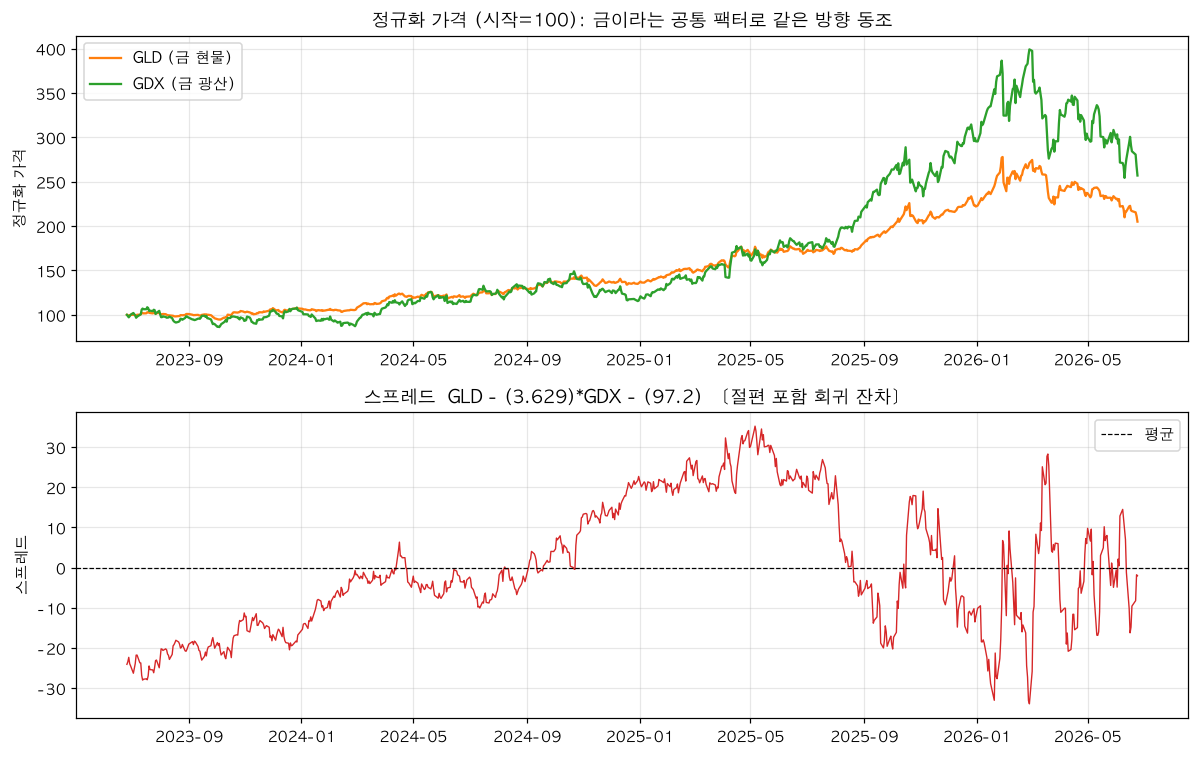

In [3]:
# ============================================================================
# 분석 1-A: 공적분 검정 + 헤지비율 + 스프레드 (원서 예제 7.2 방식)
# ============================================================================
gld, gdx = df["GLD"], df["GDX"]

# --- Engle-Granger 공적분 검정 (전체 3년) : 공적분 판정의 최종 근거 ---
coint_t, pvalue, crit = coint(gld, gdx)

# --- 헤지비율 1: 원서와 동일한 '절편 없는' OLS ---
res_noc = OLS(gld, gdx).fit()
beta_noc = res_noc.params.iloc[0]

# --- 헤지비율 2: '절편 포함' OLS ---
res_c = OLS(gld, add_constant(gdx)).fit()
const_c, beta_c = res_c.params.iloc[0], res_c.params.iloc[1]
spread = gld - beta_c * gdx - const_c        # 분석에 사용할 스프레드(절편 포함 잔차)

# --- 참고용 표준 ADF (주의: 임계값 과대평가) ---
adf_t, adf_p = adfuller(spread, maxlag=1, regression="c", autolag=None)[:2]

verdict = "공적분 성립" if pvalue < 0.05 else "공적분 미성립"
adf_note = "정상에 가까움" if adf_p < 0.05 else "비정상"

print("=" * 66)
print(" Engle-Granger 공적분 검정 (전체 3년, %d일)  <-- 최종 판정 근거" % len(df))
print("=" * 66)
print(f"  t-통계량 : {coint_t:.4f}")
print(f"  p-value  : {pvalue:.6f}")
print(f"  임계값   : 1%={crit[0]:.3f}   5%={crit[1]:.3f}   10%={crit[2]:.3f}")
print(f"  판정(5%) : {verdict}")
print("-" * 66)
print(f"  헤지비율 (절편 없음, 원서 방식) : beta = {beta_noc:+.4f}")
print(f"  헤지비율 (절편 포함)            : beta = {beta_c:+.4f},  const = {const_c:.2f}  (R^2={res_c.rsquared:.4f})")
print(f"    -> 양(+)의 헤지비율: 두 ETF가 금 가격을 같은 방향으로 공유")
print("-" * 66)
print(f"  [참고] 표준 ADF (잔차) : t={adf_t:.4f}, p={adf_p:.4f}  ->  {adf_note}")
print(f"         (주의: 표준 ADF는 헤지비율 추정 불확실성을 무시 -> 유의성 과대평가)")
print("=" * 66)

# --- 시각화 ---
fig, ax = plt.subplots(2, 1, figsize=(11, 7))

norm = df / df.iloc[0] * 100.0
ax[0].plot(norm.index, norm["GLD"], color="C1", label="GLD (금 현물)")
ax[0].plot(norm.index, norm["GDX"], color="C2", label="GDX (금 광산)")
ax[0].set_title("정규화 가격 (시작=100): 금이라는 공통 팩터로 같은 방향 동조")
ax[0].set_ylabel("정규화 가격")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(spread.index, spread, color="C3", lw=0.9)
ax[1].axhline(spread.mean(), color="k", lw=0.8, ls="--", label="평균")
ax[1].set_title("스프레드  GLD - (%.3f)*GDX - (%.1f)   [절편 포함 회귀 잔차]" % (beta_c, const_c))
ax[1].set_ylabel("스프레드"); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_analysis1_gld_gdx.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# ============================================================================
# 분석 1-B: 상관관계와 스프레드 반감기 (평균회귀 속도)
# ============================================================================
ret = df.pct_change().dropna()
corr_ret, p_ret = pearsonr(ret["GLD"], ret["GDX"])
corr_price = gld.corr(gdx)

# 스프레드(절편 포함)의 반감기 (Ornstein-Uhlenbeck): dz = theta*(z - mu) + eps
z = spread
dz = (z - z.shift()).iloc[1:]
prevz = (z.shift() - z.shift().mean()).iloc[1:]
theta = OLS(dz, prevz).fit().params.iloc[0]
halflife = -np.log(2) / theta

mult_gld = gld.iloc[-1] / gld.iloc[0]
mult_gdx = gdx.iloc[-1] / gdx.iloc[0]

print(f"일간 수익률 상관계수 : {corr_ret:+.4f}   (p = {p_ret:.1e})")
print(f"가격 상관계수        : {corr_price:+.4f}")
print(f"스프레드 반감기      : {halflife:.1f} 거래일   (theta = {theta:+.5f})")
print()
print("[해석]")
print(f"  - 수익률 상관 {corr_ret:+.3f}, 가격 상관 {corr_price:+.3f} : 같은 방향으로 강하게 동조")
print(f"  - GLD x{mult_gld:.2f}  vs  GDX x{mult_gdx:.2f} : 금 강세장에서 동반 상승")
print(f"  - 반감기 {halflife:.0f}일 : 스프레드가 평균으로 회귀하는 경향은 존재 (인버스 페어 대비 훨씬 빠름)")
print(f"  - 다만 공적분 p={pvalue:.2f} (Engle-Granger): 5% 기준 공적분은 미성립 -> 평균회귀가 '통계적으로' 확정되진 않음")

일간 수익률 상관계수 : +0.8193   (p = 4.4e-183)
가격 상관계수        : +0.9840
스프레드 반감기      : 30.7 거래일   (theta = -0.02260)

[해석]
  - 수익률 상관 +0.819, 가격 상관 +0.984 : 같은 방향으로 강하게 동조
  - GLD x2.05  vs  GDX x2.57 : 금 강세장에서 동반 상승
  - 반감기 31일 : 스프레드가 평균으로 회귀하는 경향은 존재 (인버스 페어 대비 훨씬 빠름)
  - 다만 공적분 p=0.53 (Engle-Granger): 5% 기준 공적분은 미성립 -> 평균회귀가 '통계적으로' 확정되진 않음


### 결과 해석

| 항목 | 값 |
|------|----|
| Engle–Granger t-통계량 | **-2.0010** |
| 공적분 p-value | **0.5280** |
| 임계값 (5%) | -3.344 |
| **공적분 여부 (5%)** | **미성립 (경계적)** |
| 일간 수익률 상관 | +0.8193 |
| 가격 상관 | +0.9840 |
| 헤지비율 (절편 포함) | +3.6295 (R²=0.9682) |
| 스프레드 반감기 | 약 31 거래일 |
| (참고) 표준 ADF p-value | 0.0331 |

**결론**: 최근 3년(2023–2026) GLD–GDX는 금 강세장에서 **같은 방향으로 강하게 동조**했습니다
(가격 상관 +0.98, 수익률 상관 +0.82, 양의 헤지비율 +3.63, R² 0.97). 스프레드의 반감기는 약 **31 거래일**로
평균회귀 *경향*은 존재합니다. **그러나** 공적분 판정의 올바른 기준인 **Engle–Granger 검정에서는 p-value 0.53**으로,
5% 유의수준에서 **공적분이 성립하지 않습니다(경계적).**

#### 방법론 핵심 — 표준 ADF의 함정
참고로 표시한 표준 ADF는 스프레드를 "정상(p=0.033)"이라 판정하지만, 이는 **헤지비율이 추정값이라는 사실을
무시**해 유의성을 과대평가한 결과입니다. 추정 불확실성을 반영한 **Engle–Granger 임계값**(MacKinnon)을 쓰면
같은 잔차도 공적분 기준을 통과하지 못합니다. 따라서 **공적분의 최종 판정은 `coint()`(p=0.53) → 미성립**입니다.

#### 원서와의 비교 — 공적분의 시간 의존성
원서는 GLD–GDX의 공적분을 보고했지만(특정 과거 구간), 본 분석의 2023–2026 구간에서는 **경계적으로 미성립**입니다
(첫 252일만 봐도 p≈0.43). 이는 원서가 강조한 **"공적분 관계는 데이터 기간에 따라 변한다"** 는 경고를 실증적으로
보여줍니다. 실무에서는 **롤링 공적분 검정**으로 관계의 유효 구간을 지속 모니터링해야 합니다.

> **트레이딩 함의**: GLD–GDX는 같은 방향 공통 팩터(금) 덕분에 스프레드가 빠른 평균회귀 경향(반감기 ~31일)과
> 높은 적합도(R² 0.97)를 보여 **페어 트레이딩 후보로서의 매력**은 있습니다. 다만 현재 구간에서는 공적분이
> 통계적으로 확정되지 않으므로, 진입 전 **롤링 검정으로 공적분 안정성을 확인**하고 손절·재검정 규칙을 둬야 합니다.


---

## 분석 2: 조건부 파라미터 최적화 CPO (원서 예제 7.1)

### 이론적 배경

**CPO(Conditional Parameter Optimization, 조건부 파라미터 최적화)** 는 전략의 파라미터를 *고정*하지 않고,
**매 거래일의 시장 조건에 따라 머신러닝으로 다음날 최적 파라미터를 선택**하는 기법입니다. (원서 예제 7.1, predictnow.ai)

대상 전략은 GLD–GDX **선행-지행** 관계를 이용하되 **GLD 한 종목만** 매매하는 장중 평균회귀 전략입니다.

1. 스프레드: $\text{Spread}(t) = \text{GLD}(t) - w \cdot \text{GDX}(t)$ — ($w$ = `GDX_weight`)
2. 볼린저 Z-score: $Z(t) = \dfrac{\text{Spread}(t) - \text{EMA}(t)}{\sqrt{\text{VAR}(t)}}$ (EMA/EWMA 분산, 윈도 = `lookback`)
3. 매매: $Z < -\text{entry}$ → GLD 롱 / $Z > \text{entry}$ → GLD 숏, 청산임계값 $= -0.6\times\text{entry}$, **장 마감 시 전량 청산**

세 파라미터(`GDX_weight`, `entry_threshold`, `lookback`)를 **5×10×8 = 400** 그리드로 탐색합니다.

| 방식 | 파라미터 선택 |
|------|---------------|
| **무조건부**(Unconditional) | train 구간에서 누적수익 최대인 **고정 1세트**를 골라 test에 그대로 적용 |
| **조건부 CPO**(Conditional) | RF가 *(파라미터 + 그날 시장지표)* → *익일 전략수익* 을 학습 → 매일 400조합 중 예측수익 최대 조합을 **익일** 채택 |

### ⚠️ 본 재현의 한계 (반드시 전제)
원서는 **15년치 1분봉**으로 CPO의 안정적 우위(연 17.3%→19.8%, Sharpe 1.95→2.33)를 보고했습니다.
본 노트북이 가진 데이터는 **5분봉 · 약 3개월(59 거래일)** 뿐이라, train/test 분할 시 **검증구간이 12일**에 불과합니다.
따라서 아래 성과는 **방법론 시연**일 뿐 통계적 결론의 근거가 될 수 없습니다. (룩백은 분→5분봉 개수로 환산)


In [5]:
# ============================================================================
# 분석 2-A: CPO 전략 엔진 (GLD/GDX 5분봉) — 스프레드/Z-score/백테스트, 400조합 일별수익
# ============================================================================
from sklearn.ensemble import RandomForestRegressor

g5 = pd.read_csv("gld_5min.csv", parse_dates=["datetime"]).set_index("datetime")
d5 = pd.read_csv("gdx_5min.csv", parse_dates=["datetime"]).set_index("datetime")
m5 = g5.join(d5, lsuffix="_GLD", rsuffix="_GDX", how="inner").sort_index()
m5["day"] = m5.index.normalize()
cnt = m5.groupby("day").size()
m5 = m5[m5["day"].isin(cnt[cnt == 78].index)].copy()   # 부분장(78바 미만) 제거
days = np.sort(m5["day"].unique()); day_list = list(days)
print(f"5분봉: {pd.Timestamp(days[0]).date()} ~ {pd.Timestamp(days[-1]).date()}  "
      f"({len(days)} 거래일, {len(m5)} 바, 정규장 09:30-15:55)")

gld = m5["close_GLD"].to_numpy(); gdx = m5["close_GDX"].to_numpy()
last_of_day = m5["day"].to_numpy() != np.r_[m5["day"].to_numpy()[1:], [np.datetime64("NaT")]]
gld_ret_next = np.zeros(len(m5)); gld_ret_next[:-1] = gld[1:] / gld[:-1] - 1.0
gld_ret_next[last_of_day] = 0.0          # 익일로 넘기는 수익 차단(장중만)

GDX_W  = [2, 2.5, 3, 3.5, 4]
ENTRY  = [0.2, 0.3, 0.4, 0.5, 0.7, 1, 1.25, 1.5, 2, 5]
LOOKBK = [6, 12, 18, 24, 36, 48, 72, 144]    # {30,60,90,120,180,240,360,720}분 / 5분
COST   = 0.0001                               # 편도 1bp (포지션 변화에 부과)
combos = [(w, e, L) for w in GDX_W for e in ENTRY for L in LOOKBK]
print(f"파라미터 그리드: {len(GDX_W)} x {len(ENTRY)} x {len(LOOKBK)} = {len(combos)} 조합")

def _zscore(w, L):
    s = gld - w * gdx; a = 2.0 / L
    ema = pd.Series(s).ewm(alpha=a, adjust=False).mean().to_numpy()
    var = pd.Series((s - ema) ** 2).ewm(alpha=a, adjust=False).mean().to_numpy()
    sd = np.sqrt(var)
    return np.where(sd > 1e-9, (s - ema) / sd, 0.0)

def _backtest(z, entry):
    ex = -0.6 * entry; pos = np.empty(len(z)); cur = 0
    for i in range(len(z)):                      # 장중 평균회귀 상태기계
        if cur == 0:
            if z[i] < -entry: cur = 1
            elif z[i] > entry: cur = -1
        elif cur == 1 and z[i] > ex: cur = 0
        elif cur == -1 and z[i] < -ex: cur = 0
        pos[i] = cur
        if last_of_day[i]: cur = 0               # EOD 전량 청산
    turn = np.abs(np.diff(np.r_[0.0, pos]))
    bar = pos * gld_ret_next - turn * COST
    return pd.Series(bar, index=m5.index).groupby(m5["day"]).sum().values

zc = {(w, L): _zscore(w, L) for w in GDX_W for L in LOOKBK}
DAILY = pd.DataFrame({c: _backtest(zc[(c[0], c[2])], c[1]) for c in combos}, index=days)
print("일별 전략수익 매트릭스:", DAILY.shape, "(거래일 x 조합)")

5분봉: 2026-03-31 ~ 2026-06-24  (59 거래일, 4602 바, 정규장 09:30-15:55)
파라미터 그리드: 5 x 10 x 8 = 400 조합


일별 전략수익 매트릭스: (59, 400) (거래일 x 조합)


In [6]:
# ============================================================================
# 분석 2-B: 무조건부 vs 조건부(CPO) 최적화 + 시드 안정성
# ============================================================================
def metrics(daily):
    daily = np.asarray(daily, float)
    if daily.std() == 0: return dict(ann=0, sharpe=0, sharpe_ex=0, cum=0)
    ann = daily.mean() * 252; vol = daily.std() * np.sqrt(252)
    eq = np.cumprod(1 + daily)
    return dict(ann=ann, sharpe=ann / vol if vol else 0,
                sharpe_ex=(ann - RF_ANNUAL) / vol if vol else 0,  # 초과수익(무위험금리 차감) Sharpe
                cum=eq[-1] - 1)

n = len(days); ntr = int(round(n * 0.8))
print(f"train {ntr}일 / test {n - ntr}일  (80:20 분할)")

# --- 무조건부: train 누적수익 최대 조합을 고정 -> test 익일수익 실현 ---
best = DAILY.iloc[:ntr].apply(lambda c: np.prod(1 + c) - 1).idxmax()
uncond = pd.Series([DAILY.loc[day_list[i + 1], best] for i in range(ntr - 1, n - 1)])
mu = metrics(uncond)
print(f"\n[무조건부] 선택 조합: GDX_weight={best[0]}, entry={best[1]}, lookback={best[2]}바({best[2]*5}분)")
print(f"  test: 연수익={mu['ann']*100:6.2f}%   Sharpe(raw)={mu['sharpe']:.2f}   "
      f"Sharpe(초과,rf={RF_ANNUAL*100:.1f}%)={mu['sharpe_ex']:.2f}   누적(12일)={mu['cum']*100:.2f}%")

# --- 조건부 CPO: EOD 시장조건 피처(축소셋) + RF로 익일 전략수익 예측 ---
def eod_features():
    F = {}
    for tag, c, h, l, v in [("GLD", m5.close_GLD, m5.high_GLD, m5.low_GLD, m5.volume_GLD),
                            ("GDX", m5.close_GDX, m5.high_GDX, m5.low_GDX, m5.volume_GDX)]:
        r = c.pct_change(); rng = h - l
        for L in [12, 48, 144]:
            F[f"{tag}_mom{L}"]  = c.pct_change(L)
            F[f"{tag}_vol{L}"]  = r.rolling(L).std()
            F[f"{tag}_atr{L}"]  = rng.rolling(L).mean() / c
            F[f"{tag}_volz{L}"] = (v - v.rolling(L).mean()) / v.rolling(L).std().replace(0, np.nan)
            up = r.clip(lower=0).rolling(L).mean(); dn = (-r.clip(upper=0)).rolling(L).mean()
            F[f"{tag}_rsi{L}"]  = 100 - 100 / (1 + up / dn.replace(0, np.nan))
    return pd.DataFrame(F, index=m5.index).groupby(m5["day"]).last().reindex(days).fillna(0.0)

EOD = eod_features()
print(f"EOD 시장조건 피처: {EOD.shape[1]}개 (원서 112개의 축소셋 — 짧은 표본 과적합 완화)")
P = np.array(combos, float)
Xa, Ya, RDa = [], [], []
for i in range(n - 1):                              # day i 피처 -> day i+1 수익(라벨)
    Xa.append(np.hstack([P, np.tile(EOD.loc[day_list[i]].to_numpy(), (len(combos), 1))]))
    Ya.append(DAILY.loc[day_list[i + 1]].to_numpy()); RDa.append(np.full(len(combos), i))
X = np.vstack(Xa); Y = np.concatenate(Ya); RD = np.concatenate(RDa)
trm = RD < (ntr - 1)                                # test로 라벨 누설 없도록 경계 차단

def conditional(seed):
    rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20,
                               n_jobs=4, random_state=seed).fit(X[trm], Y[trm])
    out = []
    for i in range(ntr - 1, n - 1):
        Xb = np.hstack([P, np.tile(EOD.loc[day_list[i]].to_numpy(), (len(combos), 1))])
        out.append(DAILY.loc[day_list[i + 1], combos[int(rf.predict(Xb).argmax())]])
    return pd.Series(out)

cond = {s: conditional(s) for s in range(8)}        # 시드 안정성 점검
sh  = [metrics(cond[s])["sharpe"] for s in range(8)]
shx = [metrics(cond[s])["sharpe_ex"] for s in range(8)]   # 초과수익 Sharpe
an  = [metrics(cond[s])["ann"] for s in range(8)]
print(f"\n[조건부 CPO] 8개 시드 결과:")
print(f"  Sharpe(raw)      : {min(sh):.2f} ~ {max(sh):.2f}  (중앙값 {np.median(sh):.2f})")
print(f"  Sharpe(초과,rf={RF_ANNUAL*100:.1f}%): {min(shx):.2f} ~ {max(shx):.2f}  (중앙값 {np.median(shx):.2f})")
print(f"  연수익 : {min(an)*100:.1f}% ~ {max(an)*100:.1f}%")
print(f"  -> 무조건부 Sharpe {mu['sharpe']:.2f}는 고정인데 CPO는 시드만 바꿔도 크게 출렁")
print(f"     = 60일 표본에서는 어느 쪽 우위도 통계적으로 말할 수 없음 (과적합/노이즈 지배)")

train 47일 / test 12일  (80:20 분할)

[무조건부] 선택 조합: GDX_weight=2.5, entry=1.5, lookback=36바(180분)
  test: 연수익= 22.61%   Sharpe(raw)=2.62   Sharpe(초과,rf=4.3%)=2.12   누적(12일)=1.06%
EOD 시장조건 피처: 30개 (원서 112개의 축소셋 — 짧은 표본 과적합 완화)



[조건부 CPO] 8개 시드 결과:
  Sharpe(raw)      : 1.16 ~ 9.02  (중앙값 4.40)
  Sharpe(초과,rf=4.3%): 0.73 ~ 8.43  (중앙값 3.82)
  연수익 : 11.6% ~ 67.9%
  -> 무조건부 Sharpe 2.62는 고정인데 CPO는 시드만 바꿔도 크게 출렁
     = 60일 표본에서는 어느 쪽 우위도 통계적으로 말할 수 없음 (과적합/노이즈 지배)


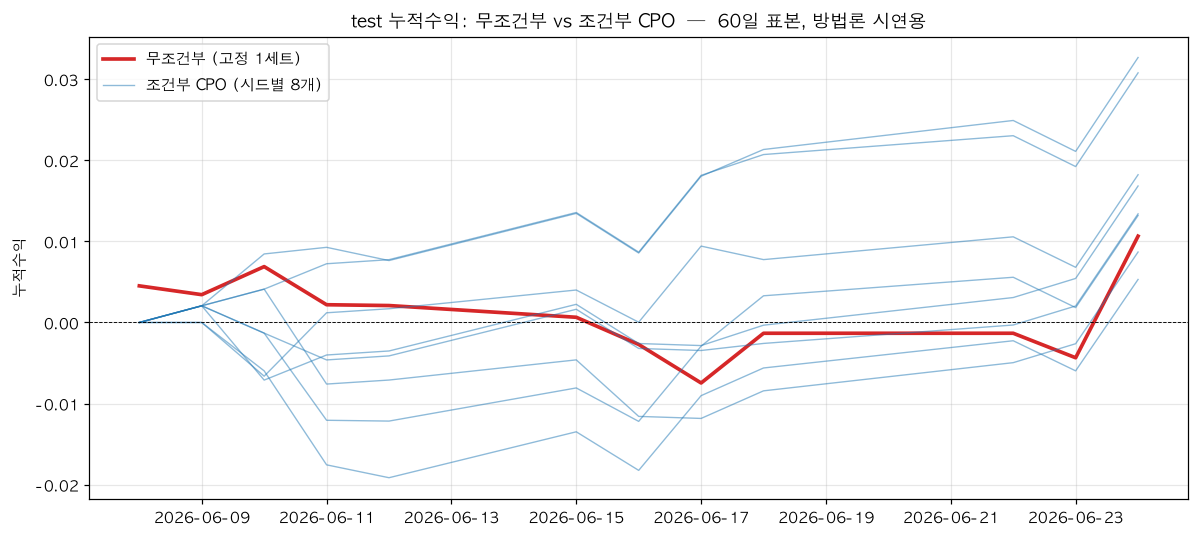

In [7]:
# ============================================================================
# 분석 2-C: test 구간 누적수익 — 무조건부 vs 조건부 CPO(시드별)
# ============================================================================
te_days = day_list[ntr:]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(te_days, np.cumprod(1 + uncond.values) - 1, color="C3", lw=2.4, label="무조건부 (고정 1세트)")
for s in range(8):
    ax.plot(te_days, np.cumprod(1 + cond[s].values) - 1, color="C0", lw=0.9, alpha=0.5,
            label="조건부 CPO (시드별 8개)" if s == 0 else None)
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_title("test 누적수익: 무조건부 vs 조건부 CPO  —  60일 표본, 방법론 시연용")
ax.set_ylabel("누적수익"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_analysis2_cpo.png", dpi=120, bbox_inches="tight"); plt.show()

### 결과 해석 (CPO)

| 항목 | 무조건부 | 조건부 CPO (시드 8개 분포) |
|------|----------|---------------------------|
| 연수익(annualized*) | **+22.6%** | +11.6% ~ +67.9% |
| Sharpe (raw) | **2.62** (고정) | 1.16 ~ 9.02 (중앙값 ~4.4) |
| **Sharpe (초과, rf=4.3%)** | **2.12** (고정) | 0.73 ~ 8.43 (중앙값 ~3.8) |
| 누적수익 (test 12일) | +1.06% | +0.53% ~ +3.27% |
| 선택 파라미터 | GDX_weight=2.5, entry=1.5, lookback=180분 | 매일 가변 |

<sub>*test 구간이 12거래일뿐이라 연율화 수치는 사실상 무의미 — 표시는 원서 표와의 형식 일치 목적.</sub>

> **주석 — 초과수익 Sharpe**: 위 Sharpe(raw)는 분자가 *원수익*입니다. 교과서 정의(초과수익 = 수익 − 무위험금리)를 적용해
> **무위험금리 4.3%를 차감**하면 무조건부 Sharpe는 **2.62 → 2.12**로 낮아집니다. 저변동성 전략일수록(분모가 작을수록) 이 차감 효과가 큽니다.

**결론**: CPO **파이프라인**(전략 → 400조합 백테스트 → 무조건부 그리드 최적화 → RF 기반 조건부 선택)은
실데이터에서 정상 작동합니다. 그러나 **성과 우열은 판정 불가**입니다:
무조건부 Sharpe는 2.62로 고정인 반면, 조건부 CPO는 **랜덤 시드만 바꿔도 Sharpe가 1.16~9.02로 요동**칩니다.

#### 왜 이렇게 불안정한가
- **표본이 너무 작다**: 59 거래일 → train 47 / **test 12일**. 게다가 시장조건 피처는 하루 1세트뿐이라
  ML이 실질적으로 본 **독립적 시장상태는 ~46개**에 불과 → 400조합 매핑을 안정적으로 학습 불가.
- **조건부가 더 취약**: 무조건부는 파라미터 1세트만 고르지만, CPO는 *매핑 함수*를 추정하므로 자유도가 커
  짧은 표본에서 과적합에 더 노출됩니다. 시드 의존성이 그 증거입니다.

#### 원서와의 비교
원서는 **15년 1분봉**으로 train에 충분한 시장국면을 담아 CPO의 **안정적** 우위(연 17.3%→19.8%, Sharpe 1.95→2.33)를
보였습니다. 본 재현이 그 결과를 못 보이는 것은 전략·구현의 문제가 아니라 **데이터 길이의 문제**이며,
이는 *"데이터가 충분하지 않으면 조건부 최적화는 오히려 독"* 이라는 실무 교훈을 역설적으로 보여줍니다.

> **다음 단계**: 더 긴 분봉(수년치)을 확보하면 동일 코드로 walk-forward 검증을 돌려 CPO의 실제 엣지를 재평가할 수 있습니다.
> 현재는 **방법론 학습용**으로만 활용하세요.


---

## 분석 3: PCA 팩터 모델 (원서 예제 7.4)

### 이론적 배경

**주성분 분석(PCA)** 으로 종목 수익률의 **공통 팩터**를 데이터에서 직접 추출하고, 이를 팩터 모델로 사용해
롱-숏 포트폴리오를 구성하는 전략입니다 (원서 예제 7.4).

1. 룩백 윈도 내 일별 수익률 행렬에 **PCA** 적용 → 상위 `numFactors`개 주성분(팩터) 추출
2. 각 종목 수익률을 팩터에 회귀(다중출력 선형회귀)하여 **팩터 노출도** 추정
3. 팩터모델 기반 **기대수익** $R_{exp}$ 계산 → 상위 `topN` **롱**, 하위 `topN` **숏** (시장중립)

### 원서(IJR)와의 차이 — 데이터에 맞춘 조정

| 항목 | 원서 (예제 7.4) | 본 분석 |
|------|-----------------|---------|
| 유니버스 | IJR(S&P SmallCap 600) 구성종목 | **Nasdaq-100** 구성종목 (101개) |
| 기간 | 수년치 | **698일(~2.7년)**, 2023-09 ~ 2026-06 |
| 룩백 | 252일 | **252일(원서와 동일)** + 60·120 비교 |
| topN | 50 | **10** (작은 유니버스에 맞춤) |
| 팩터 수 | 5 | 5 (동일) |

> 데이터 형식: 롱포맷 OHLCV(`date,ticker,...`)를 종가 와이드(날짜×종목)로 피벗해 사용합니다.
> 이제 **원서와 동일한 룩백 252일**을 쓰고도 약 445 거래일의 트레이딩 구간이 남습니다.


In [8]:
# ============================================================================
# 분석 3-A: PCA 팩터 모델 (Example 7.4) — Nasdaq-100 장기(698일), 룩백 스윕 + 비용
# ============================================================================
from sklearn.decomposition import PCA

# 롱포맷 OHLCV -> 종가 와이드(날짜 x 종목)
_long = pd.read_csv("nasdaq100_daily_ohlcv_2023-09-14.csv", parse_dates=["date"])
nd = _long.pivot(index="date", columns="ticker", values="close").sort_index().ffill()
ndret = nd.pct_change()
con = pd.read_csv("nasdaq100_constituents.csv").set_index("ticker")
spy = pd.read_csv("spy_close_2023-09-14.csv", parse_dates=[0], index_col=0)["SPY"].reindex(nd.index).ffill()
spy_full = spy.iloc[-1] / spy.iloc[0] - 1
print(f"유니버스: {nd.shape[1]}개 종목 x {nd.shape[0]}일  ({nd.index[0].date()} ~ {nd.index[-1].date()})")
print(f"벤치마크 SPY Buy&Hold (전체기간): {spy_full*100:+.2f}%")

numFactors = 5; topN = 10; COST_PCA = 0.0005      # 편도 5bp
retv = ndret.values

def pca_strategy(lookback):
    pos = np.zeros(nd.shape)
    for t in np.arange(lookback + 1, nd.shape[0]):
        R = retv[t - lookback + 1:t, :]                       # 시간 x 종목 (t 제외)
        good = np.where(np.isfinite(R).all(axis=0))[0]        # 윈도 전체 존재 종목만(미상장 제외)
        Rg = R[:, good]
        pcs = PCA(n_components=numFactors).fit_transform(Rg)  # 주성분(팩터), 시간 x 5
        X = np.column_stack([np.ones(len(pcs)), pcs])
        beta, *_ = np.linalg.lstsq(X, Rg, rcond=None)         # 팩터 노출도 (절편+5팩터, 다중출력 최소제곱)
        Rexp = (X @ beta).sum(axis=0)                         # 팩터모델 누적 기대수익
        idx = Rexp.argsort()
        pos[t, good[idx[-topN:]]] = 1                         # 고 기대수익 롱
        pos[t, good[idx[:topN]]]  = -1                        # 저 기대수익 숏
    P = pd.DataFrame(pos, index=nd.index); Psh = P.shift()
    cap = np.nansum(np.abs(Psh).values, axis=1); cap[cap == 0] = 1
    gross = np.nansum(Psh.values * retv, axis=1) / cap
    turn  = np.nansum(np.abs(P.values - Psh.values), axis=1) / cap
    net   = gross - turn * COST_PCA
    def st(r):
        r = pd.Series(r, index=nd.index).iloc[lookback + 1:]
        ann = np.nanmean(r) * 252; vol = np.nanstd(r) * math.sqrt(252)
        eq = np.cumprod(1 + r.fillna(0)); dd = eq / np.maximum.accumulate(eq) - 1
        return dict(ann=ann, vol=vol, sharpe=ann / vol if vol else 0,
                    sharpe_ex=(ann - RF_ANNUAL) / vol if vol else 0,   # 초과수익 Sharpe
                    maxdd=dd.min(), eq=eq, days=len(r))
    return st(gross), st(net), np.nanmean(turn)

print(f"\n팩터 수={numFactors}, topN={topN}(롱{topN}/숏{topN}), 비용=편도 5bp, 무위험금리={RF_ANNUAL*100:.1f}%\n")
print(f"{'lookback':>8} {'days':>5} {'회전율':>7} | {'GROSS연%':>9} {'Sharpe':>7} {'maxDD':>7} | "
      f"{'NET연%':>8} {'Sh(raw)':>8} {'Sh(초과)':>8}")
res = {}
for lb in [60, 120, 252]:
    g, nt, to = pca_strategy(lb); res[lb] = (g, nt, to)
    print(f"{lb:>8} {g['days']:>5} {to:>7.2f} | {g['ann']*100:>8.1f}% {g['sharpe']:>7.2f} {g['maxdd']*100:>6.1f}% | "
          f"{nt['ann']*100:>7.1f}% {nt['sharpe']:>8.2f} {nt['sharpe_ex']:>8.2f}")

# 벤치마크 비교: 같은 평가구간 누적수익 (전략 NET vs SPY Buy&Hold)
print(f"\n[벤치마크] 같은 구간 누적수익 (PCA 전략 NET vs SPY Buy&Hold):")
for lb in [60, 120, 252]:
    win = nd.index[lb + 1:]
    spy_bh = spy.loc[win[-1]] / spy.loc[win[0]] - 1
    net_cum = res[lb][1]["eq"].iloc[-1] - 1
    print(f"  lookback={lb:>3} ({len(win)}일): 전략 {net_cum*100:>+7.1f}%   vs   SPY {spy_bh*100:>+6.1f}%")
print(f"  (참고) SPY 전체기간: {spy_full*100:+.1f}%")

# 전체표본 PCA 설명력 (전략과 동일한 raw 수익률 기준)
pca_full = PCA().fit(ndret.dropna().values)
ev = pca_full.explained_variance_ratio_
print(f"\n전체표본 PCA 설명분산: PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%  PC3={ev[2]*100:.1f}%  누적5={ev[:5].sum()*100:.1f}%")
load1 = pd.Series(pca_full.components_[0], index=ndret.columns)
print("PC1 |로딩| 상위 5종목(섹터):")
for tk in load1.abs().sort_values(ascending=False).head(5).index:
    print(f"   {tk:<6} {load1[tk]:+.3f}  {con.loc[tk, 'ICB Industry[15]'] if tk in con.index else '?'}")

유니버스: 101개 종목 x 698일  (2023-09-14 ~ 2026-06-26)
벤치마크 SPY Buy&Hold (전체기간): +68.95%

팩터 수=5, topN=10(롱10/숏10), 비용=편도 5bp, 무위험금리=4.3%

lookback  days     회전율 |   GROSS연%  Sharpe   maxDD |    NET연%  Sh(raw)   Sh(초과)


      60   637    0.25 |     33.7%    1.51  -22.0% |    30.3%     1.36     1.17


     120   577    0.17 |     38.9%    1.65  -18.5% |    36.4%     1.54     1.36


     252   445    0.10 |     57.9%    2.37  -13.6% |    56.0%     2.29     2.11

[벤치마크] 같은 구간 누적수익 (PCA 전략 NET vs SPY Buy&Hold):
  lookback= 60 (637일): 전략  +101.9%   vs   SPY  +64.1%
  lookback=120 (577일): 전략  +115.7%   vs   SPY  +47.6%
  lookback=252 (445일): 전략  +154.8%   vs   SPY  +33.3%
  (참고) SPY 전체기간: +68.9%

전체표본 PCA 설명분산: PC1=32.1%  PC2=9.9%  PC3=5.0%  누적5=53.8%
PC1 |로딩| 상위 5종목(섹터):
   SNDK   +0.257  Technology
   MU     +0.223  Technology
   LITE   +0.214  Technology
   MRVL   +0.203  Technology
   ARM    +0.196  Technology


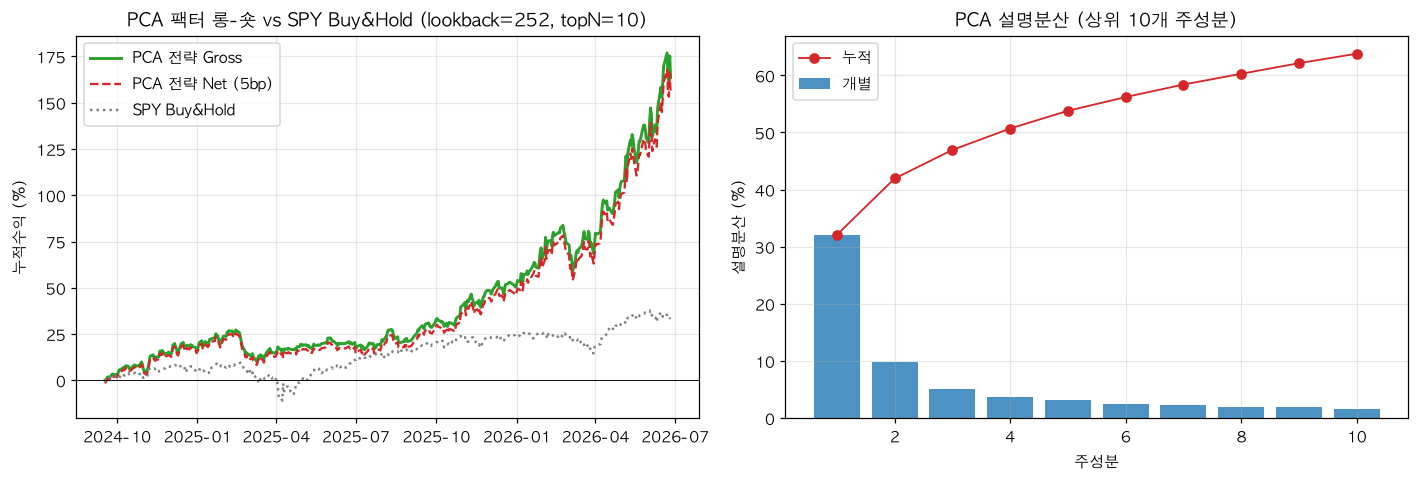

In [9]:
# ============================================================================
# 분석 3-B: 자본곡선(lookback=252, Gross/Net vs SPY) + PCA 스크리
# ============================================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
gH, nH, _ = res[252]
winH = gH["eq"].index
spy_bhH = (spy.loc[winH] / spy.loc[winH[0]] - 1) * 100
ax[0].plot(gH["eq"].index, (gH["eq"] - 1) * 100, color="C2", lw=1.9, label="PCA 전략 Gross")
ax[0].plot(nH["eq"].index, (nH["eq"] - 1) * 100, color="C3", lw=1.5, ls="--", label="PCA 전략 Net (5bp)")
ax[0].plot(winH, spy_bhH.values, color="C7", lw=1.6, ls=":", label="SPY Buy&Hold")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_title("PCA 팩터 롱-숏 vs SPY Buy&Hold (lookback=252, topN=10)")
ax[0].set_ylabel("누적수익 (%)"); ax[0].legend(); ax[0].grid(alpha=0.3)

ev = pca_full.explained_variance_ratio_[:10]
ax[1].bar(range(1, 11), ev * 100, color="C0", alpha=0.8, label="개별")
ax[1].plot(range(1, 11), np.cumsum(ev) * 100, color="C3", marker="o", lw=1.2, label="누적")
ax[1].set_title("PCA 설명분산 (상위 10개 주성분)")
ax[1].set_xlabel("주성분"); ax[1].set_ylabel("설명분산 (%)"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_analysis3_pca.png", dpi=120, bbox_inches="tight"); plt.show()

### 결과 해석 (PCA 팩터 모델)

데이터를 **약 2.7년(698 거래일)** 으로 늘려 원서와 **동일한 룩백 252일**까지 검증했습니다.

| lookback | GROSS 연수익 | NET(5bp) 연수익 | NET Sharpe (raw) | **NET Sharpe (초과, rf=4.3%)** | maxDD | 회전율 |
|---------:|-------------:|----------------:|-----------------:|-------------------------------:|------:|-------:|
| 60 (637일) | +33.7% | +30.3% | 1.36 | **1.17** | -22.0% | 0.25 |
| 120 (577일) | +38.9% | +36.4% | 1.54 | **1.36** | -18.5% | 0.17 |
| **252 (445일)** | **+57.9%** | **+56.0%** | **2.29** | **2.11** | **-13.6%** | 0.10 |

> **주석 — 초과수익 Sharpe**: NET Sharpe(raw)는 분자가 *원수익*입니다. 무위험금리 **4.3%를 차감**한 초과수익 기준으로는
> 룩백 252일 **2.29 → 2.11**, 60일 1.36 → 1.17로 낮아집니다. (분모=연변동성이 클수록 차감 효과는 작아집니다.)

**PCA 설명분산**: PC1 **32.1%**, PC2 9.9%, PC3 5.0% (누적 5개 53.8%).
PC1 최상위 로딩은 모두 **반도체/테크**(SNDK·MU·LITE·MRVL·ARM…)로, PC1 ≈ **나스닥100을 지배하는 테크·반도체 시장 팩터**입니다.
(1년 표본 때 PC1 24.2% → 2.7년 표본 32.1%로, 더 긴 기간일수록 공통 시장팩터가 또렷해집니다.)

**결과**: 더 긴 표본에서도 PCA 팩터 롱-숏은 견조하며, **룩백이 길수록 순위가 안정적(회전율↓)** 이라
순 Sharpe가 1.36(60일)→2.29(252일)로 상승합니다. 원서값(252일) 기준 **NET Sharpe 2.29 · 연 56.0% · maxDD −13.6%** 로,
1년 표본 때의 과장된 수치(Sharpe ~2.9~3.5)보다 **현실적이고 신뢰도 높은** 추정입니다.

#### ⚠️ 반드시 감안할 한계 (성과 과대평가 요인)
1. **생존 편향(survivorship bias)** — *현재* 나스닥100 구성종목으로 *과거*를 백테스트했습니다.
   "지금까지 살아남아 지수에 편입된" 종목만 보고 있어 성과가 **구조적으로 부풀려집니다.** (가장 큰 함정)
2. **단일 경로·특정 국면** — 약 2.7년이지만 단일 시장경로이며 테크 강세가 두드러진 기간입니다.
3. **거래비용 단순화** — 편도 5bp만 반영. 공매도 차입비용·시장충격·호가스프레드는 제외.
4. 원서(IJR 소형주, Sharpe 0.58)와 **유니버스·기간이 전혀 다르므로** 수치 직접 비교는 무의미합니다.

> **시사점**: 방법론(데이터에서 팩터를 직접 추출 → 시장중립 롱-숏)은 잘 작동하며, 표본을 늘리자 성과가 한층 **안정적**으로
> 수렴했습니다(룩백 252일 net Sharpe 2.29). 다만 실거래 결론을 위해서는 **생존 편향이 제거된
> 시점별 구성종목(point-in-time universe)** 으로 재검증이 필요합니다.

#### 벤치마크: 같은 기간 SPY Buy&Hold 대비

| 평가구간 | PCA 전략 (NET 누적) | SPY Buy&Hold (같은 구간) |
|---------|--------------------:|-------------------------:|
| lookback=60 (637일) | +101.9% | +64.1% |
| lookback=120 (577일) | +115.7% | +47.6% |
| **lookback=252 (445일)** | **+154.8%** | **+33.3%** |
| (참고) 전체기간 (2023-09~2026-06) | — | **+68.9%** |

전체 2.7년 동안 **SPY 보유 시 +68.9%** 였습니다. PCA 롱-숏(원서값 252일)의 순누적 **+154.8%** 는
같은 445일 SPY(+33.3%)를 크게 상회합니다. 다만 ① 전략은 **시장중립 롱-숏**이라 SPY(롱온리 베타 노출)와
**위험 성격이 근본적으로 다르고**, ② 초과성과의 상당 부분은 앞서 지적한 **생존 편향**에서 비롯됐을 가능성이 큽니다.
따라서 표면 수치보다 **생존 편향 제거 + 시점별 유니버스** 재검증 결과가 진짜 엣지를 말해줍니다.
